In [3]:
import sys
import os
import importlib
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import src.data_processing
import src.sentiment_analysis
import src.stock_data

importlib.reload(src.data_processing)
importlib.reload(src.sentiment_analysis)
importlib.reload(src.stock_data)

from src.data_processing import load_data
from src.sentiment_analysis import analyze_sentiment, aggregate_sentiment
from src.stock_data import load_stock_csv

%matplotlib inline
sns.set_style('whitegrid')

## 1. Load News Data and Calculate Sentiment

In [4]:
# Load news data
news_path = '../data/raw_analyst_ratings.csv'
if os.path.exists(news_path):
    news_df = load_data(news_path)
    print(f"Loaded {len(news_df)} news records")
    
    # Analyze sentiment
    print("Calculating sentiment scores...")
    news_df = analyze_sentiment(news_df)
    
    # Aggregate by date and stock
    sentiment_daily = aggregate_sentiment(news_df)
    print("Daily sentiment aggregated")
    display(sentiment_daily.head())
else:
    print("News data not found!")

/Users/sintayehuabaynhe/Public/panic/financial_news_sentiment/src/data_processing.py:11: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv(path, parse_dates=["date"], infer_datetime_format=True)


Loaded 1407328 news records
Calculating sentiment scores...
Daily sentiment aggregated
Daily sentiment aggregated


stock,A,AA,AAC,AADR,AAL,AAMC,AAME,AAN,AAOI,AAON,...,ZOES,ZPIN,ZQK,ZSL,ZSPH,ZTR,ZTS,ZU,ZUMZ,ZX
date,,,,,,,,,,,,,,,,,,,,,
2011-04-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-04-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-04-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-05-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Load Stock Data and Calculate Returns

In [5]:
tickers = ['AAPL', 'AMZN', 'GOOG', 'META', 'MSFT', 'NVDA']
stock_returns = pd.DataFrame()

for ticker in tickers:
    file_path = f'../data/{ticker}.csv'
    if os.path.exists(file_path):
        df = load_stock_csv(file_path)
        if not df.empty:
            # Calculate daily returns
            returns = df['Close'].pct_change()
            stock_returns[ticker] = returns

print("Stock returns calculated")
display(stock_returns.head())

Loading data from ../data/AAPL.csv...
Loading data from ../data/AMZN.csv...
Loading data from ../data/GOOG.csv...
Loading data from ../data/META.csv...
Loading data from ../data/MSFT.csv...
Loading data from ../data/NVDA.csv...
Stock returns calculated


,AAPL,AMZN,GOOG,META,MSFT,NVDA
Date,,,,,,
2009-01-02,NaN,NaN,NaN,NaN,NaN,NaN
2009-01-05,0.042204,-0.005519,0.020945,NaN,0.009345,0.018370
2009-01-06,-0.016494,0.061043,0.018321,NaN,0.011696,0.033822
2009-01-07,-0.021609,-0.020223,-0.036071,NaN,-0.060211,-0.059978
2009-01-08,0.018570,0.017082,0.009875,NaN,0.031266,-0.025522


## 3. Correlation Analysis

AAPL Correlation: 1.0000


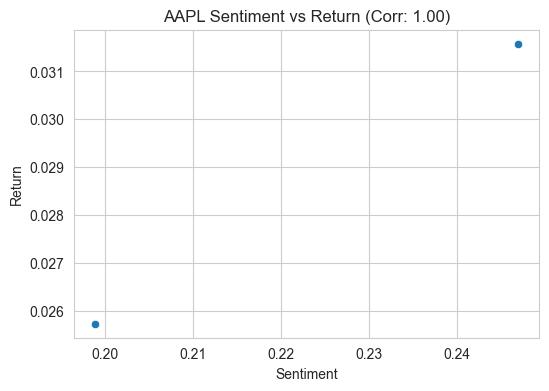

AMZN Correlation: -1.0000


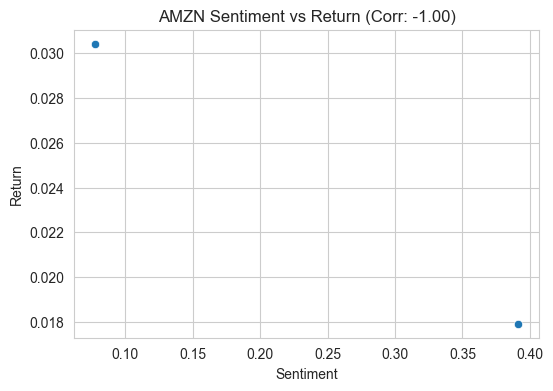

GOOG Correlation: -0.2344


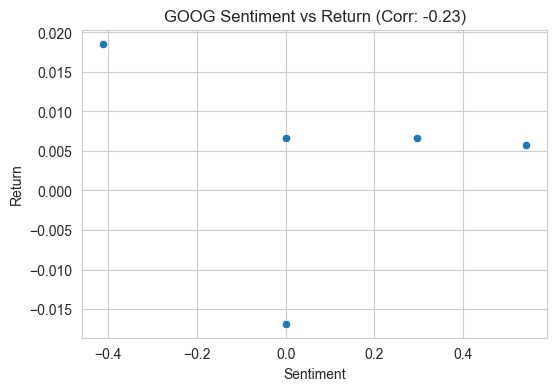

NVDA Correlation: 0.5227


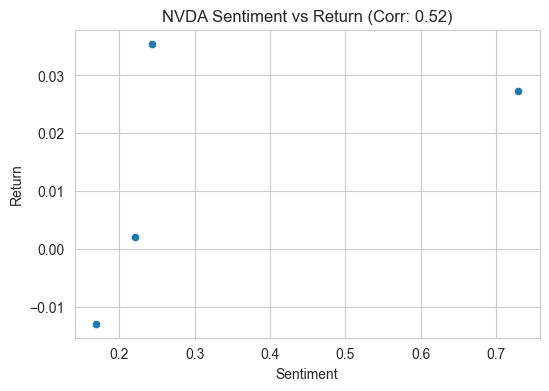

,Correlation
AAPL,1.000000
NVDA,0.522731
GOOG,-0.234365
AMZN,-1.000000


In [6]:
# Align dates
# Ensure indices are datetime and timezone-aware/naive consistent
sentiment_daily.index = pd.to_datetime(sentiment_daily.index)
stock_returns.index = pd.to_datetime(stock_returns.index)

# If one is tz-aware and other is not, convert. Usually stock data from CSV is naive.
# News data might be UTC. Let's normalize to naive date.
sentiment_daily.index = sentiment_daily.index.normalize()
stock_returns.index = stock_returns.index.normalize()

# Merge
correlation_results = {}

for ticker in tickers:
    if ticker in sentiment_daily.columns and ticker in stock_returns.columns:
        # Combine into one DF
        combined = pd.concat([sentiment_daily[ticker], stock_returns[ticker]], axis=1).dropna()
        combined.columns = ['Sentiment', 'Return']
        
        if not combined.empty:
            corr = combined['Sentiment'].corr(combined['Return'])
            correlation_results[ticker] = corr
            print(f"{ticker} Correlation: {corr:.4f}")
            
            # Scatter plot
            plt.figure(figsize=(6, 4))
            sns.scatterplot(data=combined, x='Sentiment', y='Return')
            plt.title(f'{ticker} Sentiment vs Return (Corr: {corr:.2f})')
            plt.show()

# Summary
corr_df = pd.DataFrame.from_dict(correlation_results, orient='index', columns=['Correlation'])
display(corr_df.sort_values('Correlation', ascending=False))